# ChessPublishing Atom Extraction — Working Notebook

Iterate on extraction prompt + JSONL format using real examples from the generated data.

**Input:** `data/chesspublishinga.jsonl`

---
## Setup & Data Loading

In [63]:
import os
import json
import random
import chess
import chess.svg
import openai
from IPython.display import display, SVG, Markdown
from dotenv import load_dotenv

load_dotenv()

DATA_FILE = 'data/chesspublishinga.jsonl'

def parse_json_output(text):
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"include": False, "exclude_reason": "JSON parse error", "raw": text}

print(f'Data: {DATA_FILE}')

Data: data/chesspublishinga.jsonl


In [64]:
with open(DATA_FILE) as f:
    all_entries = [json.loads(line) for line in f]

# Filter out game-level comments (no move) — we only extract atoms for moves
all_entries = [e for e in all_entries if e.get('move_uci')]

print(f'Loaded {len(all_entries)} entries from {DATA_FILE}')

Loaded 194434 entries from data/chesspublishinga.jsonl


---
## Extraction Prompt & Demos

System prompt, few-shot demos, and helper functions for the extraction LLM call.

In [65]:
SYSTEM_PROMPT = """\
You extract chess move explanations from commentary into JSON.

CRITICAL: You are a COPYIST, not an analyst. Every atom must come
DIRECTLY from the commentary text. Do NOT add your own chess knowledge.
If the commentary says "attacks e3", write that. Do NOT add "which is
a key central square" or any other analysis of your own.

Output ONLY valid JSON — no text before or after.

When include=true:
{
  "include": true,
  "fen": "<the FEN>",
  "move_san": "<the move>",
  "move_uci": "<UCI>",
  "book_commentary": "<full original commentary>",
  "reasoning": ["fact from commentary", "another fact from commentary"],
  "variation": "optional continuation line",
  "alternative": {"move": "X", "reasoning": ["..."]}
}

When include=false:
{"include": false, "exclude_reason": "why", "book_commentary": "<text>"}

RULES:
1. ONLY extract what the commentary SAYS. Never add facts it doesn't state.
2. Each atom must explain WHAT the move DOES — a threat it creates, a
   square it controls, a piece it activates, a plan it enables.
   "Qd4 prevents Black's rooks from reaching the central files" = good.
   "Nd4 is a strong resource for White" = bad (vague label, drop it).
   "Rg8 allows Black to hold on" = bad (says nothing about what Rg8 does).
3. Drop vague labels/assessments even if mixed with good atoms.
4. EXCLUDE when commentary only shows a variation line with no explanation
   of WHY the move works. A bare line + "holds" / "nothing clear" / "wins"
   is not an explanation.
5. INCLUDE when there is at least one concrete fact about the move:
   a piece, square, threat, file, diagonal, or plan.
6. Long variations (5+ moves) go in "variation", not in atoms.
7. When "alternatives" are provided (PGN sidelines with annotations and
   continuation lines), use them to populate the "alternative" field.
   Extract reasoning atoms from the annotator's comments on each
   alternative. If there are multiple alternatives, output "alternative"
   as a list of objects.
"""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 1976 chars


In [66]:
# ── Demo data from chesspublishing dataset ──────────────────────────────
# 3 demos: one concrete include, one exclude (vague label), one variation.

DEMO_DATA = [
    # Demo 1: Qc1 — concrete threat, clear include
    {
        'fen': 'r4rbk/p1Q3pp/8/1P1n4/8/q4NP1/4PRBP/5RK1 w - - 1 24',
        'move_uci': 'c7c1',
        'move_san': 'Qc1',
        'annotation': (
            'The threat to the black queen stops Black from playing '
            'his knight to e3.'
        ),
        'prev_moves': '21... Bg8 22. Qxb7 Qxa3 23. Qxc7 Nd5 24. Qc1',
        'context_fen': 'r4r1k/ppp1n1pp/3qb3/1P6/4Q3/P4NP1/4PRBP/5RK1 b - - 1 21',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': None,
    },
    # Demo 2: Nc6 — vague label, should be excluded
    {
        'fen': 'rn1qkbnr/pb1p1ppp/1p2p3/2p5/4PP2/1PN5/PBPP2PP/R2QKBNR b KQkq - 0 5',
        'move_uci': 'b8c6',
        'move_san': 'Nc6',
        'annotation': 'A perfectly natural move.',
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': None,
    },
    # Demo 3: Nxd3 — variation (loses) with concrete continuation
    {
        'fen': 'r4rk1/1p2bpp1/p1np3p/4p3/4Pn1q/1NPP1N1P/PP1B1PP1/R2QR1K1 b - - 5 14',
        'move_uci': 'f4d3',
        'move_san': 'Nxd3',
        'annotation': (
            'Nxd3 again loses since after: 27. Red1 '
            '(Black can\'t prevent Bg2-e4 winning the pinned knight.)'
        ),
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': False,
        'mainline_move': 'a5',
        'parent_comment': 'A good preparatory move, making room on a7 for the bishop.',
    },
]

DEMO_FENS = {d['fen'] for d in DEMO_DATA}

# ── Demo responses ───────────────────────────────────────────────────────
# Atoms are ONLY what the commentary states — nothing added.

_DEMO_RESPONSES = [
    # Demo 1: Qc1 — two concrete facts directly from commentary
    {
        'include': True,
        'fen': 'r4rbk/p1Q3pp/8/1P1n4/8/q4NP1/4PRBP/5RK1 w - - 1 24',
        'move_san': 'Qc1',
        'move_uci': 'c7c1',
        'reasoning': [
            'Qc1 threatens the black queen on a3.',
            'The threat to the queen stops Black from playing Nd5-e3.',
        ],
    },
    # Demo 2: Nc6 — excluded, just a vague label
    {
        'include': False,
        'exclude_reason': 'Commentary only labels the move as "natural" with no concrete reason.',
    },
    # Demo 3: Nxd3 — loses, concrete reason from commentary
    {
        'include': True,
        'fen': 'r4rk1/1p2bpp1/p1np3p/4p3/4Pn1q/1NPP1N1P/PP1B1PP1/R2QR1K1 b - - 5 14',
        'move_san': 'Nxd3',
        'move_uci': 'f4d3',
        'reasoning': [
            'Nxd3 loses because after Red1, Black cannot prevent Bg2-e4 winning the pinned knight.',
        ],
        'variation': '27. Red1 Bg2-e4',
    },
]

print(f'Demo data: {len(DEMO_DATA)} positions')

Demo data: 3 positions


In [67]:
def build_user_prompt(entry):
    """Build user prompt: FEN + move + prev_moves + context_fen + mainline_move + parent_comment + alternatives + commentary + line."""
    board = chess.Board(entry['fen'])
    move_san = entry.get('move_san') or board.san(chess.Move.from_uci(entry['move_uci']))
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    prompt = f"FEN: {entry['fen']}\n"
    prompt += f"Move played: {move_san} ({turn})\n"

    if entry.get('prev_moves'):
        prompt += f"Previous moves: {entry['prev_moves']}\n"
    if entry.get('context_fen'):
        prompt += f"Context FEN (start of prev_moves): {entry['context_fen']}\n"

    # Variation context: what the mainline played + parent framing
    if entry.get('mainline_move'):
        prompt += f"Mainline move: {entry['mainline_move']} (this entry discusses {move_san} as an alternative)\n"
    if entry.get('parent_comment'):
        prompt += f"Parent context: \"{entry['parent_comment']}\"\n"

    # Alternatives from PGN sibling variations
    if entry.get('alternatives'):
        prompt += "\nAlternative variations from the PGN:\n"
        for alt in entry['alternatives']:
            prompt += f"  - {alt['move_san']}"
            if alt.get('annotation'):
                prompt += f": {alt['annotation']}"
            if alt.get('line'):
                prompt += f" (line: {alt['line']})"
            prompt += "\n"

    prompt += f'\nCommentary: \"{entry["annotation"]}\"\n'
    if entry.get('line'):
        prompt += f"Continuation line: {entry['line']}\n"
    return prompt


def postprocess_filter(parsed_json):
    """Post-processing filters that catch what the LLM might miss."""
    if parsed_json.get('include', True) and not parsed_json.get('reasoning'):
        return False, "no reasoning atoms extracted"
    alt = parsed_json.get('alternative')
    if alt:
        alts = alt if isinstance(alt, list) else [alt]
        if any(not a.get('reasoning') for a in alts):
            return False, "alternative has no reasoning — likely not from commentary"
    return parsed_json.get('include', True), parsed_json.get('exclude_reason')

print('Helpers ready')

Helpers ready


In [68]:
def build_demos(demo_data, demo_responses):
    """Build few-shot demo messages from hardcoded data + responses."""
    demos = []
    for data, resp in zip(demo_data, demo_responses):
        r = {**resp, 'book_commentary': data['annotation']}
        demos.append({'role': 'user', 'content': build_user_prompt(data)})
        demos.append({'role': 'assistant', 'content': json.dumps(r, indent=2)})
    return demos


DEMOS = build_demos(DEMO_DATA, _DEMO_RESPONSES)

print(f'Demos: {len(DEMOS) // 2} examples')

# Show what goes to the LLM
for i in range(0, len(DEMOS), 2):
    n = i // 2 + 1
    print(f'\n{"="*60}')
    print(f'Demo {n} — USER:')
    print(DEMOS[i]['content'][:200] + '...')
    print(f'\nDemo {n} — ASSISTANT:')
    print(DEMOS[i+1]['content'])

Demos: 3 examples

Demo 1 — USER:
FEN: r4rbk/p1Q3pp/8/1P1n4/8/q4NP1/4PRBP/5RK1 w - - 1 24
Move played: Qc1 (White)
Previous moves: 21... Bg8 22. Qxb7 Qxa3 23. Qxc7 Nd5 24. Qc1
Context FEN (start of prev_moves): r4r1k/ppp1n1pp/3qb3/1P6...

Demo 1 — ASSISTANT:
{
  "include": true,
  "fen": "r4rbk/p1Q3pp/8/1P1n4/8/q4NP1/4PRBP/5RK1 w - - 1 24",
  "move_san": "Qc1",
  "move_uci": "c7c1",
  "reasoning": [
    "Qc1 threatens the black queen on a3.",
    "The threat to the queen stops Black from playing Nd5-e3."
  ],
  "book_commentary": "The threat to the black queen stops Black from playing his knight to e3."
}

Demo 2 — USER:
FEN: rn1qkbnr/pb1p1ppp/1p2p3/2p5/4PP2/1PN5/PBPP2PP/R2QKBNR b KQkq - 0 5
Move played: Nc6 (Black)

Commentary: "A perfectly natural move."
...

Demo 2 — ASSISTANT:
{
  "include": false,
  "exclude_reason": "Commentary only labels the move as \"natural\" with no concrete reason.",
  "book_commentary": "A perfectly natural move."
}

Demo 3 — USER:
FEN: r4rk1/1p2bpp1/p1np3

In [69]:
MODEL = "Qwen/Qwen3-32B"

# Local vLLM server — OpenAI-compatible API
client = openai.OpenAI(
    base_url="http://127.0.0.1:8000/v1",
    api_key="not-needed",
)

def call_llm(messages, model=MODEL, temperature=0.3):
    resp = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_completion_tokens=2048,
        extra_body={
            "chat_template_kwargs": {"enable_thinking": False},
        },
    )
    return resp.choices[0].message.content

def generate_extraction(entry, model=MODEL):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.extend(DEMOS)
    messages.append({"role": "user", "content": build_user_prompt(entry)})
    return call_llm(messages, model=model)

print(f'Model: {MODEL} (local vLLM @ http://127.0.0.1:8000)')

Model: Qwen/Qwen3-32B (local vLLM @ http://127.0.0.1:8000)


---
## Run Extraction & Review

For each sampled position: get engine analysis, run extraction, display board + commentary + atoms.

Sampled 50 positions (seed=44)
  [0] V(d=1) McShane, Luke J vs Jones, Gawain C B — c4  (75 chars)
  [1] V(d=2) Skoberne, Jure vs Milchev, Nikolay — Bxe4  (112 chars)
  [2] V(d=1) Rakhmanov, Alexander vs Mikhalchishin, Adrian — Bd6  (122 chars)
  [3] V(d=2) [alt to Ne5] Indjic, Aleksandar vs Huschenbeth, Niclas — Re1  (57 chars)
  [4] V(d=2) Medvegy, Z.. vs Aczel, Gergely — fxe4  (43 chars)
  [5] V(d=1) Shchekachev, Andrei vs Romanov, Evgeny — e4  (27 chars)
  [6] V(d=1) Pantsulaia, Levan vs Korneev, Oleg — Nd3  (91 chars)
  [7] V(d=1) Duda, Jan Krzysztof vs So, Wesley — Bh7  (98 chars)
  [8] V(d=2) Yuffa, Daniil vs Lupulescu, C.. — Qc7  (104 chars)
  [9] ML Warmerdam, Max vs Brkic, Ante — Nb3  (105 chars)
  [10] V(d=1) Donchenko, Alexander vs Esipenko, Andrey — Bb7  (78 chars)
  [11] V(d=1) [alt to e5] Donchenko, Alexander vs Esipenko, Andrey — f3  (32 chars)
  [12] V(d=1) Artemiev, Vladislav vs Ding, Liren — Bxa4  (44 chars)
  [13] V(d=3) Cheparinov, Ivan vs Drasko, Milan — Nf8  (83 c

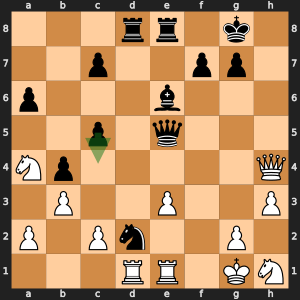

### [1/50] McShane, Luke J vs Jones, Gawain C B — Black plays c4

**Prev moves:** `20. Nh1 Ne4 21. Qxh4 Nxd2 22. Rfe1 c4`

**Parent context:** *(there's nothing better)*

> 22...c4 would have kept pieces on and left White under continuing pressure.

#### Extraction [INCLUDED]

1. 22...c4 would have kept pieces on the board.
2. 22...c4 would have left White under continuing pressure.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3rr1k1/2p2pp1/p3b3/2p1q3/Np5Q/1P2P2P/P1Pn2P1/3RR1KN b - - 1 22",
  "move_san": "c4",
  "move_uci": "c5c4",
  "reasoning": [
    "22...c4 would have kept pieces on the board.",
    "22...c4 would have left White under continuing pressure."
  ],
  "book_commentary": "22...c4 would have kept pieces on and left White under continuing pressure."
}
```
</details>

---

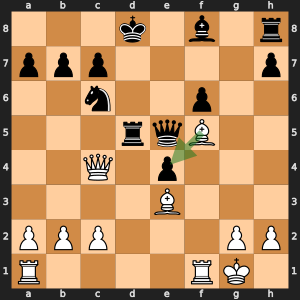

### [2/50] Skoberne, Jure vs Milchev, Nikolay — White plays Bxe4

**Prev moves:** `17... Qe8 18. Be3 Rd5 19. Qc4 Qe5 20. Bxe4`

> 20. Bxe4 and Black doesn't even have a pawn in return for his suffering, Kapnisis, S-Klokas, K/Litohoro GRE 2006

#### Extraction [EXCLUDED: Commentary only provides a source and mentions Black's material loss without explaining what Bxe4 achieves concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only provides a source and mentions Black's material loss without explaining what Bxe4 achieves concretely.",
  "book_commentary": "20. Bxe4 and Black doesn't even have a pawn in return for his suffering, Kapnisis, S-Klokas, K/Litohoro GRE 2006"
}
```
</details>

---

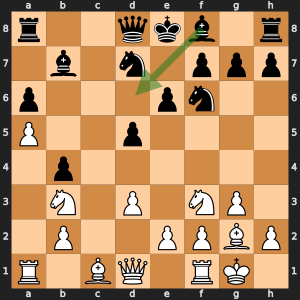

### [3/50] Rakhmanov, Alexander vs Mikhalchishin, Adrian — Black plays Bd6

**Prev moves:** `9. a5 a6 10. Nbd2 Nbd7 11. Nb3 Bd6`

**Parent context:** *Gaining more space and "isolating" the b4-pawn. White has also played:*

> Hebert,J (2376)-Bellia,F (2435) Yasmine Hammamet 2017 ½-½ (60), and now: 12. Nbd4 O-O 13. Bf4 (gives White the initiative)

#### Extraction [EXCLUDED: Commentary provides a game reference and a continuation line without explaining what the move Bd6 achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary provides a game reference and a continuation line without explaining what the move Bd6 achieves.",
  "book_commentary": "Hebert,J (2376)-Bellia,F (2435) Yasmine Hammamet 2017 \u00bd-\u00bd (60), and now: 12. Nbd4 O-O 13. Bf4 (gives White the initiative)"
}
```
</details>

---

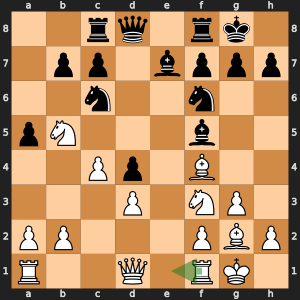

### [4/50] Indjic, Aleksandar vs Huschenbeth, Niclas — White plays Re1 (alternative to Ne5)

**Prev moves:** `9... O-O 10. Nb5 Bf5 11. Bf4 Rc8 12. Re1`

**Parent context:** *and now*

> 12. Re1 maintaining the tension, is perhaps the way to go

#### Extraction [EXCLUDED: Commentary only states that Re1 is 'perhaps the way to go' without providing concrete reasoning about what the move achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that Re1 is 'perhaps the way to go' without providing concrete reasoning about what the move achieves.",
  "book_commentary": "12. Re1 maintaining the tension, is perhaps the way to go"
}
```
</details>

---

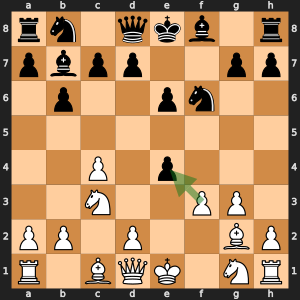

### [5/50] Medvegy, Z.. vs Aczel, Gergely — White plays fxe4

**Prev moves:** `4... f5 5. Bg2 Nf6 6. f3 fxe4 7. fxe4`

**Parent context:** *and now:*

> (Janz-Boyle in the Archives) is best met by

#### Extraction [EXCLUDED: Commentary only references a source and does not explain what the move does or why it is good.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only references a source and does not explain what the move does or why it is good.",
  "book_commentary": "(Janz-Boyle in the Archives) is best met by"
}
```
</details>

---

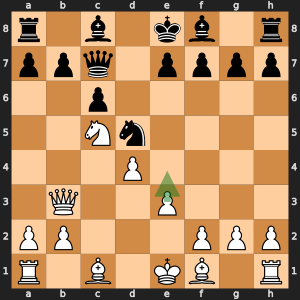

### [6/50] Shchekachev, Andrei vs Romanov, Evgeny — White plays e4

**Prev moves:** `9... Qc7 10. Nc5 Bc8 11. cxd5 Nxd5 12. e4`

> 12. e4 gives White an edge.

#### Extraction [EXCLUDED: Commentary only states that White gains an edge without explaining what the move achieves concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that White gains an edge without explaining what the move achieves concretely.",
  "book_commentary": "12. e4 gives White an edge."
}
```
</details>

---

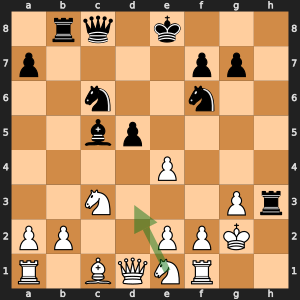

### [7/50] Pantsulaia, Levan vs Korneev, Oleg — White plays Nd3

**Prev moves:** `15... Bh3 16. Bxh3 Rxh3 17. Kg2 Qc8 18. Nd3`

**Parent context:** *is not fast enough now. After*

> 18. Nd3 and White won easily in Dubov,D (2648)-Goganov,A (2627) St Petersburg 2016 1-0 (20)

#### Extraction [EXCLUDED: Commentary only references a game result and does not provide any concrete explanation of what the move achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only references a game result and does not provide any concrete explanation of what the move achieves.",
  "book_commentary": "18. Nd3 and White won easily in Dubov,D (2648)-Goganov,A (2627) St Petersburg 2016 1-0 (20)"
}
```
</details>

---

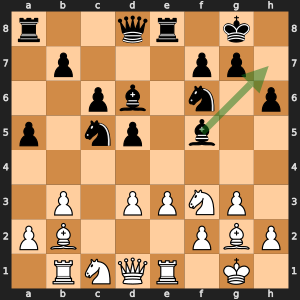

### [8/50] Duda, Jan Krzysztof vs So, Wesley — Black plays Bh7

**Prev moves:** `13. d3 Nc5 14. Nc1 h6 15. Re1 Bh7`

**Parent context:** *White weakens his light squares*

> 15...Bh7 and only Black can be better, Dolezal,C (2426)-Flores,D (2574) Buenos Aires 2017 ½-½ (41)

#### Extraction [EXCLUDED: Commentary only provides a game reference and result with no concrete explanation of what the move achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only provides a game reference and result with no concrete explanation of what the move achieves.",
  "book_commentary": "15...Bh7 and only Black can be better, Dolezal,C (2426)-Flores,D (2574) Buenos Aires 2017 \u00bd-\u00bd (41)"
}
```
</details>

---

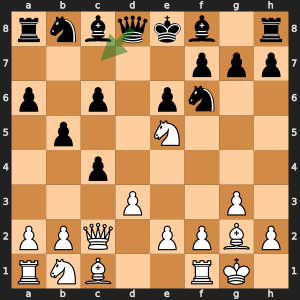

### [9/50] Yuffa, Daniil vs Lupulescu, C.. — Black plays Qc7

**Prev moves:** `6. Qc2 b5 7. Ne5 c6 8. d3 Qc7`

**Parent context:** *should now be countered by*

> 8...Qc7 when: 9. d4 (makes his last move slightly pointless.); or 9. Bf4 Bd6 10. d4 Nd5 (is much worse.)

#### Extraction [INCLUDED]

1. Qc7 is a response to White's previous moves.
2. After 9. d4, Qc7 makes White's last move slightly pointless.
3. After 9. Bf4 Bd6 10. d4, Qc7 leads to a worse position for Black with Nd5.

**Variation:** `9. d4; or 9. Bf4 Bd6 10. d4 Nd5`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnbqkb1r/5ppp/p1p1pn2/1p2N3/2p5/3P2P1/PPQ1PPBP/RNB2RK1 b kq - 0 8",
  "move_san": "Qc7",
  "move_uci": "d8c7",
  "reasoning": [
    "Qc7 is a response to White's previous moves.",
    "After 9. d4, Qc7 makes White's last move slightly pointless.",
    "After 9. Bf4 Bd6 10. d4, Qc7 leads to a worse position for Black with Nd5."
  ],
  "variation": "9. d4; or 9. Bf4 Bd6 10. d4 Nd5",
  "book_commentary": "8...Qc7 when: 9. d4 (makes his last move slightly pointless.); or 9. Bf4 Bd6 10. d4 Nd5 (is much worse.)"
}
```
</details>

---

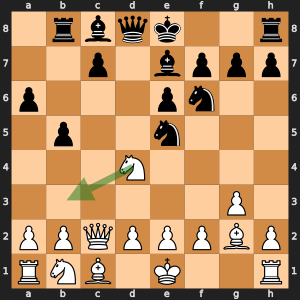

### [10/50] Warmerdam, Max vs Brkic, Ante — White plays Nb3

**Prev moves:** `8... Rb8 9. Nd4 Ngf6 10. Qc2 Ne5 11. Nb3`

**Parent context:** *White's idea was to provoke this move and then switch the queen back to the e4-square. Black could also try:*

> White appears to have clamped down on Black's thematic ...c7-c5 break, but what if they play this anyway?

#### Extraction [EXCLUDED: Commentary is speculative and does not explain what the move Nb3 does concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary is speculative and does not explain what the move Nb3 does concretely.",
  "book_commentary": "White appears to have clamped down on Black's thematic ...c7-c5 break, but what if they play this anyway?"
}
```
</details>

---

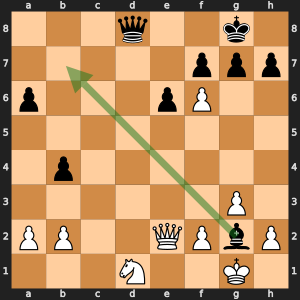

### [11/50] Donchenko, Alexander vs Esipenko, Andrey — Black plays Bb7

**Prev moves:** `26. Nd1 Bb7 27. e5 Bxg2 28. exf6 Bb7`

**Parent context:** *Dropping a pawn. Instead:*

> 28...Bb7 leaves White's king wide open to the B+Q battery on the long diagonal

#### Extraction [INCLUDED]

1. Bb7 opens a B+Q battery on the long diagonal.
2. The battery targets White's king.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3q2k1/5ppp/p3pP2/8/1p6/6P1/PP2QPbP/3N2K1 b - - 0 28",
  "move_san": "Bb7",
  "move_uci": "g2b7",
  "reasoning": [
    "Bb7 opens a B+Q battery on the long diagonal.",
    "The battery targets White's king."
  ],
  "book_commentary": "28...Bb7 leaves White's king wide open to the B+Q battery on the long diagonal"
}
```
</details>

---

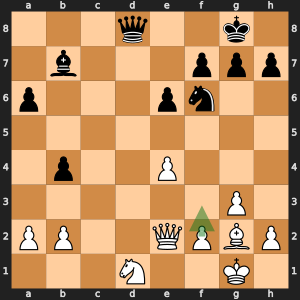

### [12/50] Donchenko, Alexander vs Esipenko, Andrey — White plays f3 (alternative to e5)

**Prev moves:** `24... Rxd8 25. Rxd8+ Qxd8 26. Nd1 Bb7 27. f3`

**Parent context:** *Black is the one asking questions, although White should be able to hold.*

**PGN alternatives:**
  - **e5**: Dropping a pawn. Instead: 27... Bxg2 28. Kxg2 Qd5+ 29. Kg1 (The best chance was to give up the e5-pawn instead of the a2-pawn:) Nd7 30. Ne3 Qxa2 (The potential to create an outside passed pawn, as well as the weakness of White's remaining pawns, make this very di...) 31. Qd1 Nf8 32. Qd4 a5 33. Nc4

> 27. f3 should be drawn with care

#### Extraction [EXCLUDED: Commentary only states the assessment "should be drawn with care" with no concrete explanation of what f3 does or why it is drawn.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states the assessment \"should be drawn with care\" with no concrete explanation of what f3 does or why it is drawn.",
  "book_commentary": "27. f3 should be drawn with care"
}
```
</details>

---

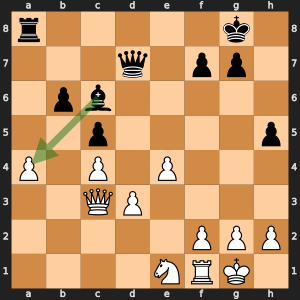

### [13/50] Artemiev, Vladislav vs Ding, Liren — Black plays Bxa4

**Prev moves:** `25. e4 Ra8 26. Nc3 Bxc3 27. Qxc3 Bxa4`

**Parent context:** *Now White has two extra pawns, which outweigh other factors in the position.*

> 27...Bxa4 is only slightly better for White.

#### Extraction [EXCLUDED: Commentary only provides an assessment ("only slightly better for White") with no concrete explanation of what the move does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only provides an assessment (\"only slightly better for White\") with no concrete explanation of what the move does.",
  "book_commentary": "27...Bxa4 is only slightly better for White."
}
```
</details>

---

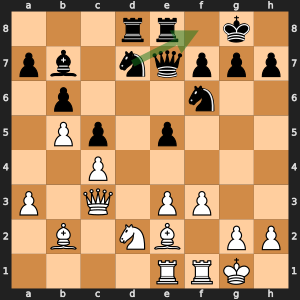

### [14/50] Cheparinov, Ivan vs Drasko, Milan — Black plays Nf8

**Prev moves:** `15. b5 Qe7 16. Nd2 Rcd8 17. f3 Nf8`

> 17...Nf8 with chances to both sides, Roussel Roozmon, T-Hecht, H/Kitchener CAN 2006

#### Extraction [EXCLUDED: Commentary only states the move is balanced with chances to both sides and provides tournament context, with no concrete explanation of what the move does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states the move is balanced with chances to both sides and provides tournament context, with no concrete explanation of what the move does.",
  "book_commentary": "17...Nf8 with chances to both sides, Roussel Roozmon, T-Hecht, H/Kitchener CAN 2006"
}
```
</details>

---

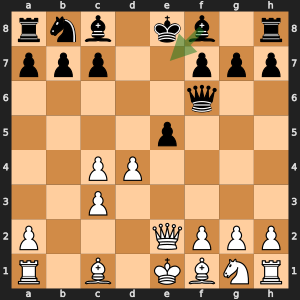

### [15/50] Nepomniachtchi, Ian vs Aleksandrov, Aleksej — Black plays Be7

**Prev moves:** `6. bxc3 Qxf6 7. d4 e5 8. Qe2 Be7`

**Parent context:** *has been tried by some very strong players, but*

> 8...Be7 has proven to be a fully satisfactory response.

#### Extraction [EXCLUDED: Commentary only states that the move is satisfactory without explaining what it achieves concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that the move is satisfactory without explaining what it achieves concretely.",
  "book_commentary": "8...Be7 has proven to be a fully satisfactory response."
}
```
</details>

---

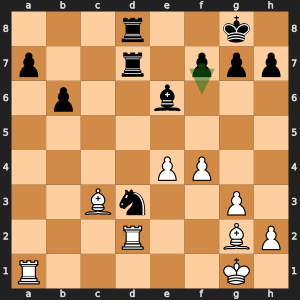

### [16/50] Gelfand, Boris vs Inarkiev, Ernesto — Black plays f6

**Prev moves:** `30. Rd2 Rc7 31. Be5 Rcd7 32. Bc3 f6`

**Parent context:** *Here:*

> Neutralizing any further advance of White's pawns.

#### Extraction [INCLUDED]

1. f6 neutralizes any further advance of White's pawns.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3r2k1/p2r1ppp/1p2b3/8/4PP2/2Bn2P1/3R2BP/R5K1 b - - 10 32",
  "move_san": "f6",
  "move_uci": "f7f6",
  "reasoning": [
    "f6 neutralizes any further advance of White's pawns."
  ],
  "book_commentary": "Neutralizing any further advance of White's pawns."
}
```
</details>

---

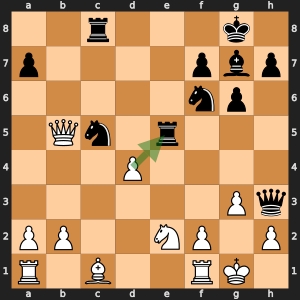

### [17/50] Bruzon Batista, Lazaro vs De la Paz Perdomo, Frank — White plays dxe5 (alternative to Nf4)

**Prev moves:** `17... Qh3 18. d4 Rfe8 19. Ne2 Rxe5 20. dxe5`

**Parent context:** *Critical.*

> 20. dxe5 when: 20... Ng4 (forces mate.)

#### Extraction [INCLUDED]

1. After 20. dxe5, 20... Ng4 forces mate.

**Variation:** `20... Ng4`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "2r3k1/p4pbp/5np1/1Qn1r3/3P4/6Pq/PP2NP1P/R1B2RK1 w - - 0 20",
  "move_san": "dxe5",
  "move_uci": "d4e5",
  "reasoning": [
    "After 20. dxe5, 20... Ng4 forces mate."
  ],
  "variation": "20... Ng4",
  "book_commentary": "20. dxe5 when: 20... Ng4 (forces mate.)"
}
```
</details>

---

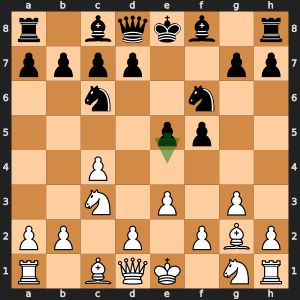

### [18/50] Santos Ruiz, Miguel vs Nestorovic, Nikola — Black plays e4 (alternative to d5)

**Prev moves:** `3. Bg2 f5 4. Nc3 Nf6 5. e3 e4`

**Parent context:** *The reversed Grand Prix Attack is one of Black's more ambitious setups against 1 c4 and 2 g3.*

**PGN alternatives:**
  - **d5**: Black has several "normal" moves here such as 5...g6 and 5...Bb4, but 5...d5 has scored well and is the second most common move according to the database. Nevertheless, it is not fully endorsed by modern engines. It appears that White can get a decent reversed Open Sicilian style position, as indeed happens in the opening phase of this game. Another attempt to press on the light squares (that have been weakened by 5 e3) is the line: 6. Nxd5 (A more accurate move order is:) Nxd5 (Here Black can instead try:) 7. cxd5 Nb4 8. d3 (Instead:) Nxd5 9. Nf3 Bd6 (Trading a pair of bishops doesn't help Black's cause, since it speeds up White's development, for example:) 10. O-O Nf6 11. b4 (A natural "Sicilian" expanding move, but here White could also try:) Qe7; or 6. cxd5 (which reduces Black's options, and now) Nb4 7. d3 Nbxd5 8. Nxd5 Nxd5 (transposes to the game)

> 5...e4 when a high-level game continued

#### Extraction [EXCLUDED: Commentary only mentions that the move occurred in a high-level game with no explanation of what the move accomplishes.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only mentions that the move occurred in a high-level game with no explanation of what the move accomplishes.",
  "book_commentary": "5...e4 when a high-level game continued"
}
```
</details>

---

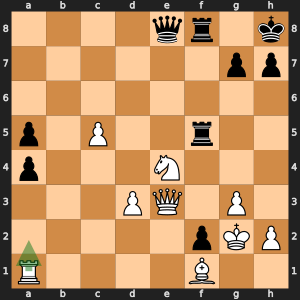

### [19/50] Malakhov, Vladimir vs Nepomniachtchi, Ian — White plays Ra2

**Prev moves:** `34... Re5 35. Kg2 Qe8 36. c5 Ref5 37. Ra2`

**Parent context:** *allows White to consolidate*

> 37. Ra2 and White should win

#### Extraction [EXCLUDED: Commentary only states that White should win without explaining what Ra2 achieves concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that White should win without explaining what Ra2 achieves concretely.",
  "book_commentary": "37. Ra2 and White should win"
}
```
</details>

---

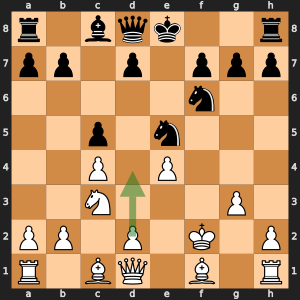

### [20/50] Poldauf, Dirk vs Timman, Jan H — White plays d4

**Prev moves:** `5... Bxf2+ 6. Kxf2 Nxe5 7. e4 c5 8. d4`

**Parent context:** *when Ivanchuk's*

> 8. d4 gives White the edge.

#### Extraction [EXCLUDED: Commentary only states that White gains an edge without explaining what the move accomplishes concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that White gains an edge without explaining what the move accomplishes concretely.",
  "book_commentary": "8. d4 gives White the edge."
}
```
</details>

---

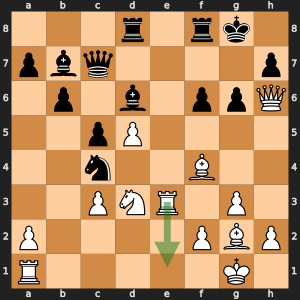

### [21/50] Carlsen, Magnus vs Aronian, Levon — White plays Ree1 (alternative to Re4)

**Prev moves:** `17... g6 18. Qh6 f6 19. Nd3 Nc4 20. Ree1`

> (+= Pelletier) is less convincing: 20... g5 21. Bxd6 Rxd6

#### Extraction [EXCLUDED: Commentary only provides a variation with an assessment ("is less convincing") but no concrete explanation of what Ree1 does or why it is less convincing.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only provides a variation with an assessment (\"is less convincing\") but no concrete explanation of what Ree1 does or why it is less convincing.",
  "book_commentary": "(+= Pelletier) is less convincing: 20... g5 21. Bxd6 Rxd6"
}
```
</details>

---

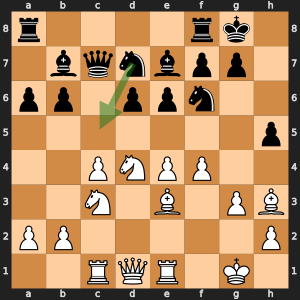

### [22/50] Seel, Christian vs Shevchenko, Kirill — Black plays Nc5

**Prev moves:** `12. Rc1 O-O 13. f4 h5 14. Bh3 Nc5`

**Parent context:** *Eyeing sacrifices on the e6-square. Instead:*

**PGN alternatives:**
  - **Ng4**: 14...Ng4 sacs a pawn. After: 15. Bxg4 hxg4 16. Qxg4 Nf6 17. Qh3 Qd7 18. Bf2 Rfc8 19. b3 b5 (Milanovic,D (2481)-Perunovic,M (2415) Kraljevo 2014 1-0 (37) and now) 20. g4 (gives White attacking chances.)
  - **Rac8**: 14...Rac8 looks best, for example: 15. Bf2 Qd8 (Black's queen stays closer to the kingside) 16. Qe2 Qe8 (and Black has things under control.)

> Black is hitting the e4-pawn, but White now calls his bluff. Alternatively: 15. b4 Ncxe4 (Or:) 16. Nxe6 (White strikes with this thematic sacrifice.) Qxc4 17. Nb1 (Not the most active square for the knight. Another game that reached this far instead saw:) Nc3 (Returning the favour. Here:) 18. Nxc3 fxe6 19. Qe2 (Even stronger was:) d5 20. Bxe6+ Kh8

...

**Alternative: Ng4**
  - Ng4 sacrifices a pawn.

**Alternative: Rac8**
  - Rac8 looks best as Black's queen stays closer to the kingside.

**Variation:** `15. b4 Ncxe4 16. Nxe6 Qxc4 17. Nb1 Nc3 18. Nxc3 fxe6 19. Qe2 d5 20. Bxe6+ Kh8`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r4rk1/1bqnbpp1/pp1ppn2/7p/2PNPP2/2N1B1PB/PP5P/2RQR1K1 b - - 1 14",
  "move_san": "Nc5",
  "move_uci": "b8c5",
  "reasoning": [
    "Nc5 hits the e4-pawn.",
    "White calls Black's bluff."
  ],
  "variation": "15. b4 Ncxe4 16. Nxe6 Qxc4 17. Nb1 Nc3 18. Nxc3 fxe6 19. Qe2 d5 20. Bxe6+ Kh8",
  "alternative": [
    {
      "move": "Ng4",
      "reasoning": [
        "Ng4 sacrifices a pawn."
      ],
      "variation": "15. Bxg4 hxg4 16. Qxg4 Nf6 17. Qh3 Qd7 18. Bf2 Rfc8 19. b3 b5 20. g4"
    },
    {
      "move": "Rac8",
      "reasoning": [
        "Rac8 looks best as Black's queen stays closer to the kingside."
      ],
      "variation": "15. Bf2 Qd8 16. Qe2 Qe8"
    }
  ],
  "book_commentary": "Black is hitting the e4-pawn, but White now calls his bluff. Alternatively: 15. b4 Ncxe4 (Or:) 16. Nxe6 (White strikes with this thematic sacrifice.) Qxc4 17. Nb1 (Not the most active square for the knight. Another game that reached this far instead saw:) Nc3 (Returning the favour. Here:) 18. Nxc3 fxe6 19. Qe2 (Even stronger was:) d5 20. Bxe6+ Kh8"
}
```
</details>

---

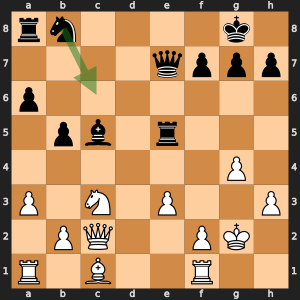

### [23/50] Ivanchuk, Vassily vs Yam, Alex — Black plays Nc6 (alternative to Qb7+)

**Prev moves:** `16. Ndxe4 Nxc3 17. Nxc3 Bxg2 18. Kxg2 Nc6`

**Parent context:** *The dust has settled, White has a solid extra pawn but Black has free play for his pieces.*

**PGN alternatives:**
  - **Qb7+**: Provoking White to play a move he wants to play anyway.

> 18...Nc6 is the most natural,

#### Extraction [EXCLUDED: Commentary only labels the move as "most natural" with no concrete reason.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only labels the move as \"most natural\" with no concrete reason.",
  "book_commentary": "18...Nc6 is the most natural,"
}
```
</details>

---

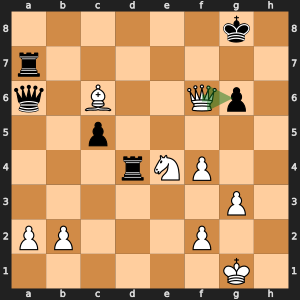

### [24/50] Karpov, Anatoly vs Topalov, Veselin — White plays Qxg6+

**Prev moves:** `27... Qxa6 28. Rxd4 Rxd4 29. Qf6+ Kg8 30. Qxg6+`

**Parent context:** *Flashy, but the mundane*

> The queen and two minor pieces make mincemeat of the black position.

#### Extraction [EXCLUDED: Commentary is a vague assessment with no concrete explanation of what Qxg6+ achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary is a vague assessment with no concrete explanation of what Qxg6+ achieves.",
  "book_commentary": "The queen and two minor pieces make mincemeat of the black position."
}
```
</details>

---

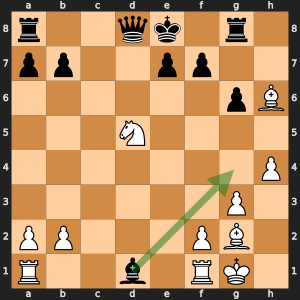

### [25/50] Anton Guijarro, David vs Leko, Peter — Black plays Bg4

**Prev moves:** `13. Bxd4 Bxd1 14. Bxg7 Rg8 15. Bxh6 Bg4`

**Parent context:** *leads to highly interesting complications, where White has a temporary queen sacrifice at his disposal:*

> The bishop needs to quickly arrive at e6 to block the e-file and later eliminate the d5-knight.

#### Extraction [INCLUDED]

1. Bg4 needs to quickly arrive at e6 to block the e-file.
2. Bg4 needs to later eliminate the d5-knight.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r2qk1r1/pp2pp2/6pB/3N4/7P/6P1/PP3PB1/R2b1RK1 b q - 0 15",
  "move_san": "Bg4",
  "move_uci": "b7g4",
  "reasoning": [
    "Bg4 needs to quickly arrive at e6 to block the e-file.",
    "Bg4 needs to later eliminate the d5-knight."
  ],
  "book_commentary": "The bishop needs to quickly arrive at e6 to block the e-file and later eliminate the d5-knight."
}
```
</details>

---

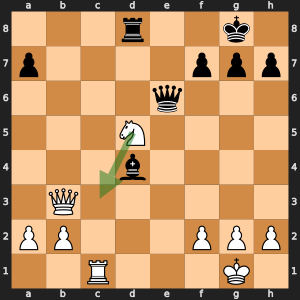

### [26/50] Sulskis, Sarunas vs Nabaty, Tamir — White plays Nc3 (alternative to Qc4)

**Prev moves:** `19... Qe6 20. Rfd1 Rd8 21. Rxd4 Bxd4 22. Nc3`

**Parent context:** *This looks obvious enough but I think it lets his advantage slip.*

**PGN alternatives:**
  - **Qc4**: It looks strange to just return the pawn as now Black will be level on material and have what chances are going.

> 22. Nc3 was a better idea.

#### Extraction [EXCLUDED: Commentary only states that Nc3 was a better idea without providing any concrete reasoning about what the move does or why it is better.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that Nc3 was a better idea without providing any concrete reasoning about what the move does or why it is better.",
  "book_commentary": "22. Nc3 was a better idea."
}
```
</details>

---

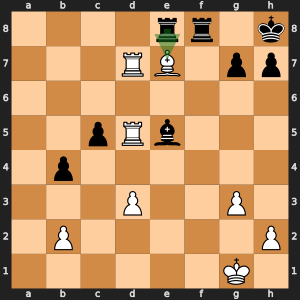

### [27/50] Aronian, Levon vs Smirnov, Pavel — Black plays Rxe7

**Prev moves:** `27. exd3 Rce8 28. Bg5 Be5 29. Be7 Rxe7`

**Parent context:** *There is nothing to be gained by capturing on c5:*

> Absolutely correct, other moves lead to big problems: 30. Rxe7 Bxb2 (Black has only one pawn for the exchange, but it is a powerful passed pawn, and all the other pawns can be defended b...) 31. Rf7 (A little back-rank trick.) Re8 32. Rfd7 (White's best bet is to exchange a pair of rooks, doubling on the seventh achieves nothing because the g7-pawn is defe...) Bd4+ 33. Kg2 b3 34. Rd8 Rg8 35. R5d7 b2

#### Extraction [INCLUDED]

1. Rxe7 is absolutely correct because other moves lead to big problems for White.
2. After Rxe7, Black can play Bxb2, gaining a powerful passed pawn.
3. White's other pawns can be defended by Black.

**Variation:** `30. Rxe7 Bxb2 31. Rf7 Re8 32. Rfd7 Bd4+ 33. Kg2 b3 34. Rd8 Rg8 35. R5d7 b2`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "4rr1k/3RB1pp/8/2pRb3/1p6/3P2P1/1P5P/6K1 b - - 4 29",
  "move_san": "Rxe7",
  "move_uci": "e8e7",
  "reasoning": [
    "Rxe7 is absolutely correct because other moves lead to big problems for White.",
    "After Rxe7, Black can play Bxb2, gaining a powerful passed pawn.",
    "White's other pawns can be defended by Black."
  ],
  "variation": "30. Rxe7 Bxb2 31. Rf7 Re8 32. Rfd7 Bd4+ 33. Kg2 b3 34. Rd8 Rg8 35. R5d7 b2",
  "book_commentary": "Absolutely correct, other moves lead to big problems: 30. Rxe7 Bxb2 (Black has only one pawn for the exchange, but it is a powerful passed pawn, and all the other pawns can be defended b...) 31. Rf7 (A little back-rank trick.) Re8 32. Rfd7 (White's best bet is to exchange a pair of rooks, doubling on the seventh achieves nothing because the g7-pawn is defe...) Bd4+ 33. Kg2 b3 34. Rd8 Rg8 35. R5d7 b2"
}
```
</details>

---

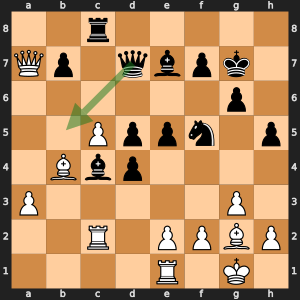

### [28/50] Markowski, Tomasz vs Genov, Petar — Black plays Qb5

**Prev moves:** `26. a3 Rc8 27. Bg2 Qd7 28. Rc2 Qb5`

**Parent context:** *Maybe it is time to break in the centre by*

> Time to round-up the c5-pawn.

#### Extraction [INCLUDED]

1. Qb5 targets the c5-pawn.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "2r5/Qp1qbpk1/6p1/2Pppn1p/1Bbp4/P5P1/2R1PPBP/4R1K1 b - - 4 28",
  "move_san": "Qb5",
  "move_uci": "d7b5",
  "reasoning": [
    "Qb5 targets the c5-pawn."
  ],
  "book_commentary": "Time to round-up the c5-pawn."
}
```
</details>

---

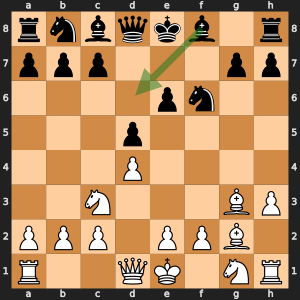

### [29/50] Rosen, E.. vs Williams, Simon Kim — Black plays Bd6

**Prev moves:** `5. Bxg3 Nf6 6. Nc3 d5 7. Bg2 Bd6`

**Parent context:** *Putting a stop to any ...Ne4 ideas and preparing e4. White has a lot of untried ideas here, and this is an interesting position to explore.*

**PGN alternatives:**
  - **c5**: 7...c5 is a fighting move. Black aims for counterplay against White's centre.

> A sensible move in a Blitz game, but there are some other options.

#### Extraction [INCLUDED]

1. Bd6 puts a stop to any ...Ne4 ideas.
2. Bd6 prepares e4 for Black.

**Alternative: c5**
  - c5 is a fighting move.
  - c5 aims for counterplay against White's centre.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnbqkb1r/ppp3pp/4pn2/3p4/3P4/2N3BP/PPP1PPB1/R2QK1NR b KQkq - 1 7",
  "move_san": "Bd6",
  "move_uci": "c8d6",
  "reasoning": [
    "Bd6 puts a stop to any ...Ne4 ideas.",
    "Bd6 prepares e4 for Black."
  ],
  "alternative": {
    "move": "c5",
    "reasoning": [
      "c5 is a fighting move.",
      "c5 aims for counterplay against White's centre."
    ]
  },
  "book_commentary": "A sensible move in a Blitz game, but there are some other options."
}
```
</details>

---

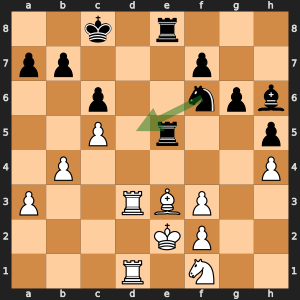

### [30/50] Nihal, Sarin vs Tang, Andrew — Black plays Nd5

**Prev moves:** `22. Rd3 Bh6 23. Rhd1 c6 24. Nf1 Nd5`

**Parent context:** *White is making good progress, but it is a Blitz game so anything is possible!*

> The pressure against e3 is very uncomfortable.

#### Extraction [INCLUDED]

1. Nd5 exerts pressure against e3.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "2k1r3/pp3p2/2p2npb/2P1r2p/1P5P/P2RBP2/4KP2/3R1N2 b - - 1 24",
  "move_san": "Nd5",
  "move_uci": "f4d5",
  "reasoning": [
    "Nd5 exerts pressure against e3."
  ],
  "book_commentary": "The pressure against e3 is very uncomfortable."
}
```
</details>

---

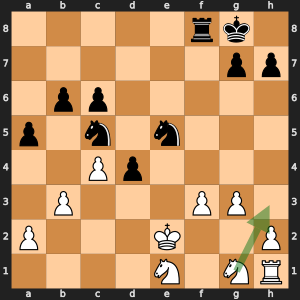

### [31/50] Bagaturov, Giorgi vs Kuzubov, Yuriy — White plays Nh3

**Prev moves:** `25... Rd8 26. Ne1 Rf8 27. Ke2 a5 28. Nh3`

**Parent context:** *This attempt to improve the knight unfortunately allows his opponent too much leeway.*

> Finally coming into the game, but a bit late to stem the tide!

#### Extraction [EXCLUDED: Commentary only provides a vague assessment without concrete facts about what Nh3 does or why it is late.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only provides a vague assessment without concrete facts about what Nh3 does or why it is late.",
  "book_commentary": "Finally coming into the game, but a bit late to stem the tide!"
}
```
</details>

---

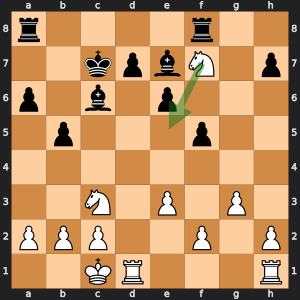

### [32/50] Jones, Gawain C B vs Diaz Perez, Michel — White plays Ne5

**Prev moves:** `13... Be7 14. Nxf7 Rhf8 15. Bxc6 Bxc6 16. Ne5`

**Parent context:** *when*

> 16. Ne5 would be excellent for White, since: 16... Bxh1 17. Rxd7+ Kb6 18. Rxe7 (gives him two good pawns and plenty of ongoing activity for the exchange.)

#### Extraction [INCLUDED]

1. Ne5 gives White two good pawns and ongoing activity for the exchange.

**Variation:** `16... Bxh1 17. Rxd7+ Kb6 18. Rxe7`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r4r2/2kpbN1p/p1b1p3/1p3p2/8/2N1P1P1/PPP2P1P/2KR3R w - - 0 16",
  "move_san": "Ne5",
  "move_uci": "f3e5",
  "reasoning": [
    "Ne5 gives White two good pawns and ongoing activity for the exchange."
  ],
  "variation": "16... Bxh1 17. Rxd7+ Kb6 18. Rxe7",
  "book_commentary": "16. Ne5 would be excellent for White, since: 16... Bxh1 17. Rxd7+ Kb6 18. Rxe7 (gives him two good pawns and plenty of ongoing activity for the exchange.)"
}
```
</details>

---

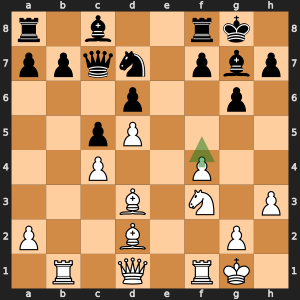

### [33/50] Hebden, Mark vs Kett, Timothy — White plays f5

**Prev moves:** `13... e6 14. O-O exd5 15. exd5 Nd7 16. f5`

**Parent context:** *Logically preventing Black from freeing his position with an exchange on f3. Kett responds by desperately trying to challenge in the centre.*

> And now it's time for full speed ahead. Hebden made much of his living in the Eighties from the Grand Prix Attack and White's attack here is just as direct and potentially deadly.

#### Extraction [EXCLUDED: Commentary is purely evaluative and historical, with no concrete explanation of what f5 does or its tactical/con positional consequences.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary is purely evaluative and historical, with no concrete explanation of what f5 does or its tactical/con positional consequences.",
  "book_commentary": "And now it's time for full speed ahead. Hebden made much of his living in the Eighties from the Grand Prix Attack and White's attack here is just as direct and potentially deadly."
}
```
</details>

---

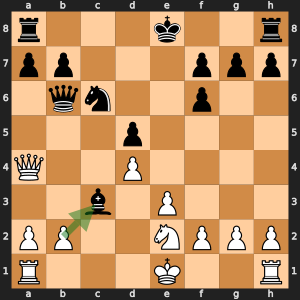

### [34/50] Letelier Martner, Rene vs Fischer, Robert James — White plays bxc3

**Prev moves:** `12... Nc6 13. Ne2 Bb4+ 14. Nbc3 Bxc3+ 15. bxc3`

**Parent context:** *And here Black should play 3...Ne4 transposing into a sub-line of the 2...Ne4 Trompowsky after 2.Bf4 (Bh4) c5 where 3.f3 is normal and 3.c3 considered rightly as dubious, again because of the b2 problem. A good illustration of this estimation is provided by the famous game Terentiev, (possibly Denis and not Anatoli) against Joe Gallagher, analysed in this section.*

> 15. bxc3 like a variation in the same game is this time obviously in White's favour.

#### Extraction [EXCLUDED: Commentary only states that the move is 'obviously in White's favour' without providing concrete reasoning about what the move does or its effects.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that the move is 'obviously in White's favour' without providing concrete reasoning about what the move does or its effects.",
  "book_commentary": "15. bxc3 like a variation in the same game is this time obviously in White's favour."
}
```
</details>

---

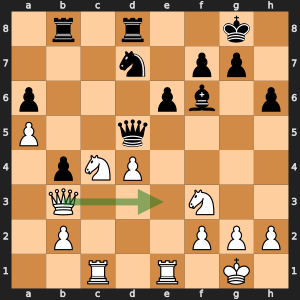

### [35/50] Prie, Eric vs Philippe, Christophe — White plays Qe3

**Prev moves:** `21... Rab8 22. Rac1 Qb5 23. Qb3 Qd5 24. Qe3`

**Parent context:** *Transposition into the ending was only justified by the hope of placing an obvious fork, and would prove rapidly disastrous.*

> The queen looks less active than on a4, but White can then transfer his attention towards the idea Nfe5 without fearing the intermediate Nc5 after the exchange on e5 anymore, and besides, the recapture with the d-pawn will provide a support to the key d6-square for the Nc4.

#### Extraction [INCLUDED]

1. Qe3 allows White to transfer attention towards the idea Nfe5.
2. Qe3 removes the fear of Nc5 after the exchange on e5.
3. The recapture with the d-pawn will provide support to the key d6-square for the Nc4.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "1r1r2k1/3n1pp1/p3pb1p/P2q4/1pNP4/1Q3N2/1P3PPP/2R1R1K1 w - - 7 24",
  "move_san": "Qe3",
  "move_uci": "b3e3",
  "reasoning": [
    "Qe3 allows White to transfer attention towards the idea Nfe5.",
    "Qe3 removes the fear of Nc5 after the exchange on e5.",
    "The recapture with the d-pawn will provide support to the key d6-square for the Nc4."
  ],
  "book_commentary": "The queen looks less active than on a4, but White can then transfer his attention towards the idea Nfe5 without fearing the intermediate Nc5 after the exchange on e5 anymore, and besides, the recapture with the d-pawn will provide a support to the key d6-square for the Nc4."
}
```
</details>

---

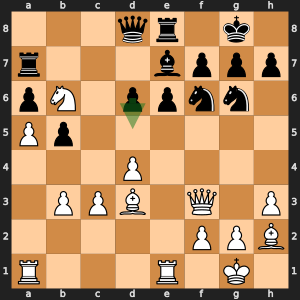

### [36/50] Kramnik, Vladimir vs Duda, Jan Krzysztof — Black plays d5

**Prev moves:** `16. Nb6 Ra7 17. b3 Bxf3 18. Qxf3 d5`

**Parent context:** *Having already made inroads on the queenside, naturally White wants to advance further there by deploying his c-pawn.*

> 18...d5 contesting the c4-square and intending to follow with ...Nd7.

#### Extraction [INCLUDED]

1. 18...d5 contests the c4-square.
2. 18...d5 intends to follow with ...Nd7.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3qr1k1/r3bppp/pN1ppnn1/Pp6/3P4/1PPB1Q1P/5PPB/R3R1K1 b - - 0 18",
  "move_san": "d5",
  "move_uci": "d6d5",
  "reasoning": [
    "18...d5 contests the c4-square.",
    "18...d5 intends to follow with ...Nd7."
  ],
  "book_commentary": "18...d5 contesting the c4-square and intending to follow with ...Nd7."
}
```
</details>

---

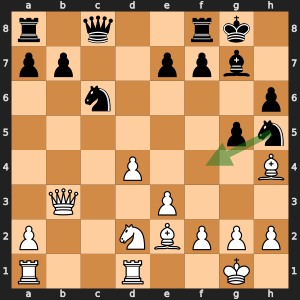

### [37/50] Karpov, Anatoly vs Gelfand, Boris — Black plays Nf4

**Prev moves:** `15. Bh4 g5 16. Nd2 cxd4 17. cxd4 Nf4`

**Parent context:** *By having momentarily saved the tempo h2-h3, White makes this defence possible.*

> A well known one.

#### Extraction [EXCLUDED: Commentary only labels the move as "well known" with no concrete reason.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only labels the move as \"well known\" with no concrete reason.",
  "book_commentary": "A well known one."
}
```
</details>

---

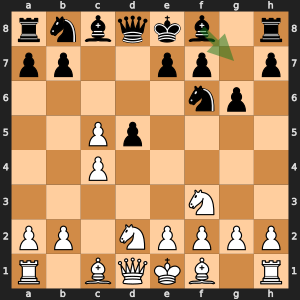

### [38/50] Vidit, Santosh Gujrathi vs Grandelius, Nils — Black plays Bg7

**Prev moves:** `3. Nbd2 d5 4. c4 c5 5. dxc5 Bg7`

**Parent context:** *, as in a game from Gibraltar:*

> 5...Bg7 is the critical line, as we've noted before

#### Extraction [EXCLUDED: Commentary only labels the move as the "critical line" with no concrete reason.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only labels the move as the \"critical line\" with no concrete reason.",
  "book_commentary": "5...Bg7 is the critical line, as we've noted before"
}
```
</details>

---

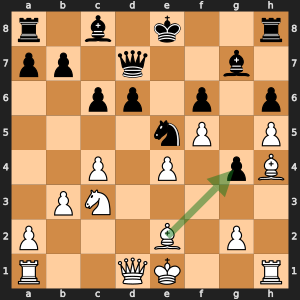

### [39/50] Babula, Vlastimil Sr vs Zwardon, V.. — White plays Bxg4

**Prev moves:** `14... Qd7 15. f5 Ne5 16. b3 c6 17. Bxg4`

**Parent context:** *e.g.*

> (finally the pawn can be captured safely)

#### Extraction [INCLUDED]

1. Bxg4 captures the pawn safely.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r1b1k2r/pp1q2b1/2pp1p1p/4nP1P/2P1P1pB/1PN5/P3B1P1/R2QK2R w KQkq - 0 17",
  "move_san": "Bxg4",
  "move_uci": "f3g4",
  "reasoning": [
    "Bxg4 captures the pawn safely."
  ],
  "book_commentary": "(finally the pawn can be captured safely)"
}
```
</details>

---

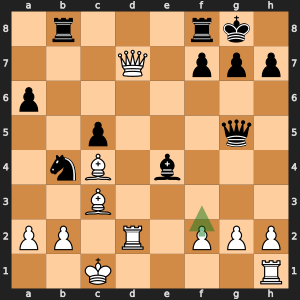

### [40/50] Rakhmanov, Alexander vs Nepomniachtchi, Ian — White plays f3 (alternative to Re1)

**Prev moves:** `16... Bg5+ 17. Nxg5 Qxg5+ 18. Rd2 Rbb8 19. f3`

**Parent context:** *White's most dynamic is*

> 19. f3 offers nothing after: 19... Bd3 20. Bxd3 Rbd8 21. Qg4 Nxd3+ 22. Kc2

#### Extraction [INCLUDED]

1. 19. f3 offers nothing because after 19... Bd3, 20. Bxd3 Rbd8, 21. Qg4 Nxd3+ 22. Kc2.

**Variation:** `19... Bd3 20. Bxd3 Rbd8 21. Qg4 Nxd3+ 22. Kc2`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "1r3rk1/3Q1ppp/p7/2p3q1/1nB1b3/2B5/PP1R1PPP/2K4R w - - 2 19",
  "move_san": "f3",
  "move_uci": "f2f3",
  "reasoning": [
    "19. f3 offers nothing because after 19... Bd3, 20. Bxd3 Rbd8, 21. Qg4 Nxd3+ 22. Kc2."
  ],
  "variation": "19... Bd3 20. Bxd3 Rbd8 21. Qg4 Nxd3+ 22. Kc2",
  "book_commentary": "19. f3 offers nothing after: 19... Bd3 20. Bxd3 Rbd8 21. Qg4 Nxd3+ 22. Kc2"
}
```
</details>

---

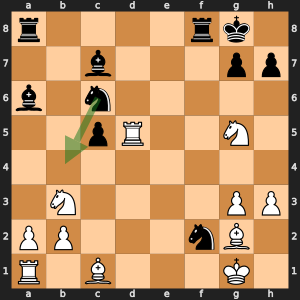

### [41/50] Perez Ponsa, Federico vs Dubov, Daniil — Black plays Nb4

**Prev moves:** `17. Ng5 Qxd1 18. Rxd1 Nxf2 19. Rxd5 Nb4`

**Parent context:** *e.g.*

> Stupak, K - Kovalev, V Yerevan 2016, and now: 20. Rd7 (just looks bad for Black.)

#### Extraction [EXCLUDED: Commentary only states the move "looks bad for Black" without explaining what the move does or why it is bad.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states the move \"looks bad for Black\" without explaining what the move does or why it is bad.",
  "book_commentary": "Stupak, K - Kovalev, V Yerevan 2016, and now: 20. Rd7 (just looks bad for Black.)"
}
```
</details>

---

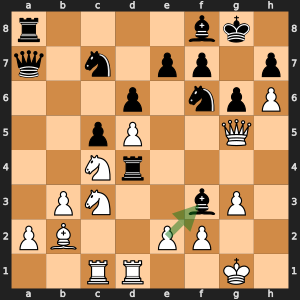

### [42/50] Timofeev, Artyom vs Durarbeyli, Vasif — White plays exf3

**Prev moves:** `30... Qa7 31. Bf3 Bg4 32. Qg5 Bxf3 33. exf3`

**Parent context:** *Not the best plan.*

> White's doubled pawns are actually quite useful, as Black is denied access to both of e4 and g4.

#### Extraction [INCLUDED]

1. White's doubled pawns are useful as they deny Black access to e4.
2. White's doubled pawns are useful as they deny Black access to g4.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r4bk1/q1n1pp1p/3p1npP/2pP2Q1/2Nr4/1PN2bP1/PB2PP2/2RR2K1 w - - 0 33",
  "move_san": "exf3",
  "move_uci": "e4f3",
  "reasoning": [
    "White's doubled pawns are useful as they deny Black access to e4.",
    "White's doubled pawns are useful as they deny Black access to g4."
  ],
  "book_commentary": "White's doubled pawns are actually quite useful, as Black is denied access to both of e4 and g4."
}
```
</details>

---

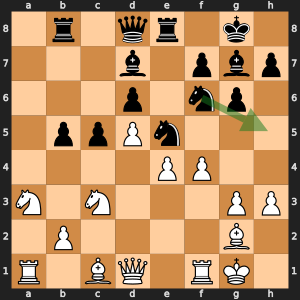

### [43/50] Kemp, Peter vs Ward, Christopher — Black plays Nh5

**Prev moves:** `15. e4 b5 16. axb5 axb5 17. f4 Nh5`

**Parent context:** *Simply threatening ...b4*

> 17...Nh5 is also possible for Black, but now Black doesn't have to take any risks to reach a good position.

#### Extraction [EXCLUDED: Commentary only states that the move is possible and that Black doesn't have to take risks, without concrete explanation of what the move achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that the move is possible and that Black doesn't have to take risks, without concrete explanation of what the move achieves.",
  "book_commentary": "17...Nh5 is also possible for Black, but now Black doesn't have to take any risks to reach a good position."
}
```
</details>

---

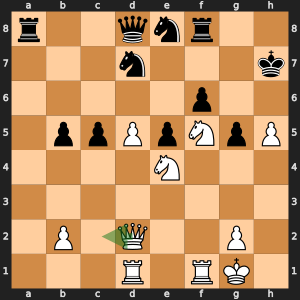

### [44/50] Hoffman, Alejandro vs Rodi, Luis Ernesto — White plays Qc2

**Prev moves:** `25... hxg6 26. h5 g5 27. Nf5+ Kh7 28. Qc2`

**Parent context:** *Now the f5-square will become White property as well.*

> Lining up some nasty discovered attacks along the b1-h7 diagonal.

#### Extraction [INCLUDED]

1. Qc2 lines up discovered attacks along the b1-h7 diagonal.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r2qnr2/3n3k/5p2/1ppPpNpP/4N3/8/1P1Q2P1/3R1RK1 w - - 2 28",
  "move_san": "Qc2",
  "move_uci": "d1c2",
  "reasoning": [
    "Qc2 lines up discovered attacks along the b1-h7 diagonal."
  ],
  "book_commentary": "Lining up some nasty discovered attacks along the b1-h7 diagonal."
}
```
</details>

---

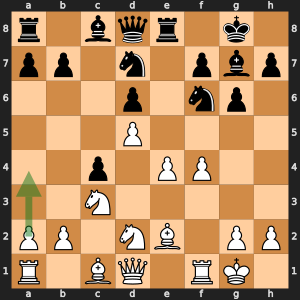

### [45/50] Maisuradze, Nino vs Velpula, Sarayu — White plays a4 (alternative to Kh1)

**Prev moves:** `9... Nbd7 10. O-O Re8 11. Nd2 c4 12. a4`

**Parent context:** *Opening the a7-g1 diagonal and clearing c5 for Black's knight.*

> 12. a4 but then: 12... Nc5 13. Bf3 Bd7 14. Kh1 Rc8 (gave Black excellent counterplay in Hansen,C (2500)-Larsen,B (2520) Naestved 1985.)

#### Extraction [EXCLUDED: Commentary only provides a variation and a game reference without concrete explanation of what the move achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only provides a variation and a game reference without concrete explanation of what the move achieves.",
  "book_commentary": "12. a4 but then: 12... Nc5 13. Bf3 Bd7 14. Kh1 Rc8 (gave Black excellent counterplay in Hansen,C (2500)-Larsen,B (2520) Naestved 1985.)"
}
```
</details>

---

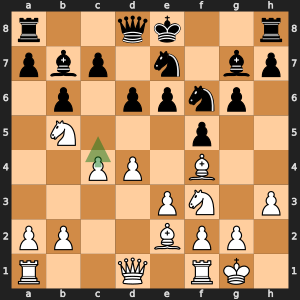

### [46/50] Nihal, Sarin vs Maghsoodloo, Parham — White plays c5

**Prev moves:** `8... Bg7 9. Nc3 Ne7 10. Nb5 d6 11. c5`

**Parent context:** *(more time is squandered)*

> Grachev, B - Morozevich, A Moscow blitz 2008, with very strong threats.

#### Extraction [EXCLUDED: Commentary only references a game and mentions strong threats without explaining what the move achieves concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only references a game and mentions strong threats without explaining what the move achieves concretely.",
  "book_commentary": "Grachev, B - Morozevich, A Moscow blitz 2008, with very strong threats."
}
```
</details>

---

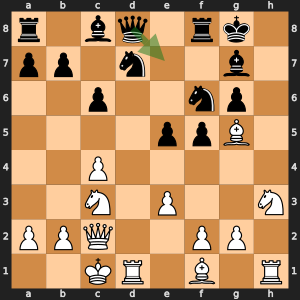

### [47/50] Sanal, Vahap vs Nikac, Predrag — Black plays Qe7

**Prev moves:** `10. h5 c6 11. hxg6 hxg6 12. O-O-O Qe7`

> (Black will be able to play ...Nc5 next move against virtually anything)

#### Extraction [INCLUDED]

1. Qe7 allows Black to play ...Nc5 on the next move against virtually anything.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r1bq1rk1/pp1n2b1/2p2np1/4ppB1/2P5/2N1P2N/PPQ2PP1/2KR1B1R b - - 1 12",
  "move_san": "Qe7",
  "move_uci": "d8e7",
  "reasoning": [
    "Qe7 allows Black to play ...Nc5 on the next move against virtually anything."
  ],
  "book_commentary": "(Black will be able to play ...Nc5 next move against virtually anything)"
}
```
</details>

---

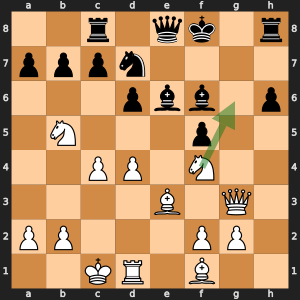

### [48/50] Narciso Dublan, Marc vs Movsziszian, Karen — White plays Ng6+ (alternative to Nxa7)

**Prev moves:** `14... Nd7 15. Nb5 Bf6 16. Qg3 Rc8 17. Ng6+`

**Parent context:** *Because of Black's lack of organization, the primitive threat to the c7-square is awkward to meet.*

> 17. Ng6+ is also good

#### Extraction [EXCLUDED: Commentary only states that the move is 'also good' without providing any concrete explanation of what the move does or why it is good.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that the move is 'also good' without providing any concrete explanation of what the move does or why it is good.",
  "book_commentary": "17. Ng6+ is also good"
}
```
</details>

---

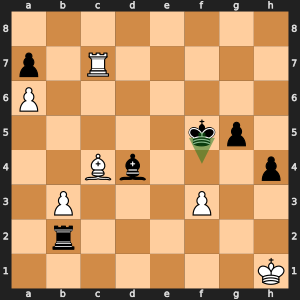

### [49/50] Ding, Liren vs Nepomniachtchi, Ian — Black plays Kf4

**Prev moves:** `51. Rf7+ Bf6 52. Rxc7 Bd4+ 53. Kh1 Kf4`

**Parent context:** *An error, as now Black's threats become overwhelming.*

> 53...Kf4 with a quick mate.

#### Extraction [INCLUDED]

1. Kf4 allows Black to threaten a quick mate.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "8/p1R5/P7/5kp1/2Bb3p/1P3P2/1r6/7K b - - 2 53",
  "move_san": "Kf4",
  "move_uci": "e5f4",
  "reasoning": [
    "Kf4 allows Black to threaten a quick mate."
  ],
  "book_commentary": "53...Kf4 with a quick mate."
}
```
</details>

---

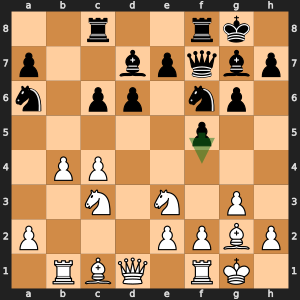

### [50/50] Kraai, Jesse vs Antal, Gergely — Black plays f4

**Prev moves:** `12. b4 Rc8 13. Nc2 Qf7 14. Ne3 f4`

**Parent context:** *In this theoretical position White has various tries*

> Ushenina, A-Hort, V Marianske Lazne 2008, (see the archives).

#### Extraction [EXCLUDED: Commentary only references a game and provides no explanation of what the move does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only references a game and provides no explanation of what the move does.",
  "book_commentary": "Ushenina, A-Hort, V Marianske Lazne 2008, (see the archives)."
}
```
</details>

---

In [70]:
# ── Config (change these and re-run just this cell) ──
SEED = 44
NUM_POSITIONS = 50

rng = random.Random(SEED)
sample_indices = rng.sample(range(len(all_entries)), NUM_POSITIONS)
samples = [all_entries[i] for i in sorted(sample_indices)]

print(f'Sampled {NUM_POSITIONS} positions (seed={SEED})')
for i, e in enumerate(samples):
    tag = 'ML' if e['is_mainline'] else f'V(d={e["variation_depth"]})'
    ml = f' [alt to {e["mainline_move"]}]' if e.get('mainline_move') else ''
    print(f'  [{i}] {tag}{ml} {e["game"]} — {e["move_san"]}  ({len(e["annotation"])} chars)')

for idx, entry in enumerate(samples):
    board = chess.Board(entry['fen'])
    move = chess.Move.from_uci(entry['move_uci'])
    move_san = board.san(move)
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    # Run extraction
    raw_text = generate_extraction(entry)
    parsed = parse_json_output(raw_text)

    # Post-process filter
    pp_include, pp_reason = postprocess_filter(parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason

    # ── Display ──
    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)], size=300)
    display(SVG(svg))

    meta = entry.get('metadata', {})
    game = meta.get('White', '?') + ' vs ' + meta.get('Black', '?')

    # Title with variation info
    title = f'### [{idx+1}/{len(samples)}] {game} — {turn} plays {move_san}'
    if entry.get('mainline_move'):
        title += f' (alternative to {entry["mainline_move"]})'
    display(Markdown(title))

    if entry.get('prev_moves'):
        display(Markdown(f'**Prev moves:** `{entry["prev_moves"]}`'))

    if entry.get('parent_comment'):
        display(Markdown(f'**Parent context:** *{entry["parent_comment"]}*'))

    # Show PGN alternatives (input context)
    if entry.get('alternatives'):
        alt_lines = []
        for a in entry['alternatives']:
            line = f'  - **{a["move_san"]}**'
            if a.get('annotation'):
                line += f': {a["annotation"]}'
            if a.get('line'):
                line += f' *(line: {a["line"]})*'
            alt_lines.append(line)
        display(Markdown('**PGN alternatives:**\n' + '\n'.join(alt_lines)))

    display(Markdown(f'> {entry["annotation"]}'))

    if entry.get('line'):
        display(Markdown(f'**Continuation line:** `{entry["line"]}`'))

    # Extraction result
    included = parsed.get('include', False)
    tag = 'INCLUDED' if included else f'EXCLUDED: {parsed.get("exclude_reason", "?")}'
    display(Markdown(f'#### Extraction [{tag}]'))

    reasoning = parsed.get('reasoning', [])
    if reasoning:
        display(Markdown('\n'.join(f'{i+1}. {a}' for i, a in enumerate(reasoning))))

    alt = parsed.get('alternative')
    if alt:
        alts = alt if isinstance(alt, list) else [alt]
        for a in alts:
            r_list = a.get('reasoning', [])
            display(Markdown(
                f'**Alternative: {a.get("move", "?")}**\n' +
                '\n'.join(f'  - {r}' for r in r_list)
            ))

    if parsed.get('variation'):
        display(Markdown(f'**Variation:** `{parsed["variation"]}`'))

    # Full structured JSON
    display(Markdown(f'<details><summary>Full JSON</summary>\n\n```json\n{json.dumps(parsed, indent=2)}\n```\n</details>'))

    display(Markdown('---'))